# Naive Rehearsal

## Naive Rehearsal

**Key Idea**: Store and replay past task data using a simple memory buffer.

**Methodology**: Extends the available dataset by dumping new samples into a fixed-size FIFO (First-In, First-Out) memory buffer. While simple to implement, the lack of careful sampling and structured batch balancing means model performance favors the most recently learned tasks.

### Setup and Data Loading

In [6]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from src import (
    set_seed, ClassIncrementalMNIST, SimpleNN, 
    evaluate_cumulative_tasks, plot_learning_curves
)

set_seed(42)

num_tasks = 5
classes_per_task = 2
input_size = 28 * 28
hidden_size = 256
output_size = 10
learning_rate = 0.005
epochs_per_task = 5
batch_size = 32
replay_buffer_size = 2000

class_splits = [list(range(i * classes_per_task, (i + 1) * classes_per_task)) for i in range(num_tasks)]

train_tasks = [ClassIncrementalMNIST(root="./data", train=True, classes=class_splits[i]) for i in range(num_tasks)]
test_tasks = [ClassIncrementalMNIST(root="./data", train=False, classes=class_splits[i]) for i in range(num_tasks)]

train_loaders = [DataLoader(train_tasks[i], batch_size=batch_size, shuffle=True) for i in range(num_tasks)]

### Naive Rehearsal Training Function

In [7]:
def train_with_naive_rehearsal(model, task_idx, train_loader, criterion, optimizer, replay_data, replay_labels, epochs=5):
    current_data, current_labels = [], []
    for batch_x, batch_y in train_loader:
        current_data.append(batch_x)
        current_labels.append(batch_y)
    current_data = torch.cat(current_data)
    current_labels = torch.cat(current_labels)
    
    if len(replay_data) > 0:
        combined_data = torch.cat([current_data, replay_data[:min(len(replay_data), replay_buffer_size)]])
        combined_labels = torch.cat([current_labels, replay_labels[:min(len(replay_labels), replay_buffer_size)]])
    else:
        combined_data, combined_labels = current_data, current_labels
    
    combined_loader = DataLoader(TensorDataset(combined_data, combined_labels), batch_size=batch_size, shuffle=True)
    task_train_loss = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0
        for inputs, labels in combined_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(combined_loader)
        epoch_acc = 100 * correct / total
        task_train_loss.append(epoch_loss)
        print(f'Task {task_idx+1}, Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')
    return task_train_loss

### Sequential Training Loop with Naive Rehearsal

In [8]:
model = SimpleNN(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

accuracies = []
training_losses = []
replay_data = []
replay_labels = []

for task_idx in range(num_tasks):
    print(f"\n{'='*50}\nTraining on Task {task_idx+1}: Classes {class_splits[task_idx]}\n{'='*50}")
    
    r_data_t = torch.tensor(replay_data) if len(replay_data) > 0 else torch.empty(0)
    r_labels_t = torch.tensor(replay_labels) if len(replay_labels) > 0 else torch.empty(0)
    
    task_loss = train_with_naive_rehearsal(
        model, task_idx, train_loaders[task_idx], criterion, optimizer,
        r_data_t, r_labels_t, epochs=epochs_per_task
    )
    training_losses.extend(task_loss)
    
    acc = evaluate_cumulative_tasks(model, test_tasks[:task_idx + 1])
    accuracies.append(acc)
    print(f"\nModel Accuracy after Task {task_idx + 1}: {acc:.2f}%")
    
    for x, y in train_tasks[task_idx]:
        if len(replay_data) < replay_buffer_size:
            replay_data.append(x.numpy())
            replay_labels.append(y)
        else:
            replay_data.pop(0)
            replay_labels.pop(0)
            replay_data.append(x.numpy())
            replay_labels.append(y)


Training on Task 1: Classes [0, 1]
Task 1, Epoch 1/5, Loss: 0.4166, Accuracy: 98.46%
Task 1, Epoch 2/5, Loss: 0.0362, Accuracy: 99.69%
Task 1, Epoch 3/5, Loss: 0.0214, Accuracy: 99.73%
Task 1, Epoch 4/5, Loss: 0.0161, Accuracy: 99.76%
Task 1, Epoch 5/5, Loss: 0.0133, Accuracy: 99.77%

Model Accuracy after Task 1: 99.91%

Training on Task 2: Classes [2, 3]
Task 2, Epoch 1/5, Loss: 0.7072, Accuracy: 84.41%
Task 2, Epoch 2/5, Loss: 0.2250, Accuracy: 94.42%
Task 2, Epoch 3/5, Loss: 0.1772, Accuracy: 95.05%
Task 2, Epoch 4/5, Loss: 0.1566, Accuracy: 95.41%
Task 2, Epoch 5/5, Loss: 0.1446, Accuracy: 95.76%

Model Accuracy after Task 2: 95.89%

Training on Task 3: Classes [4, 5]
Task 3, Epoch 1/5, Loss: 0.8306, Accuracy: 80.06%
Task 3, Epoch 2/5, Loss: 0.2759, Accuracy: 93.33%
Task 3, Epoch 3/5, Loss: 0.2049, Accuracy: 94.62%
Task 3, Epoch 4/5, Loss: 0.1735, Accuracy: 95.30%
Task 3, Epoch 5/5, Loss: 0.1554, Accuracy: 95.62%

Model Accuracy after Task 3: 66.57%

Training on Task 4: Classes [6

### Metrics & Visualization

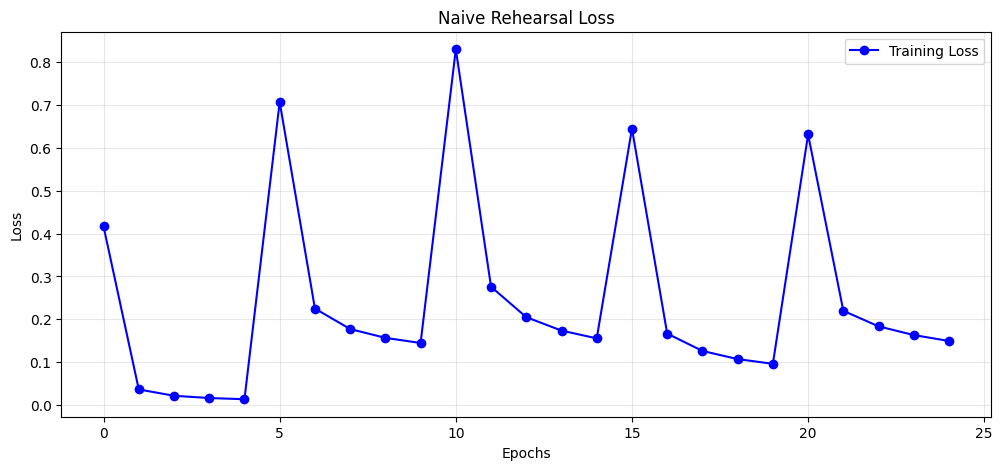

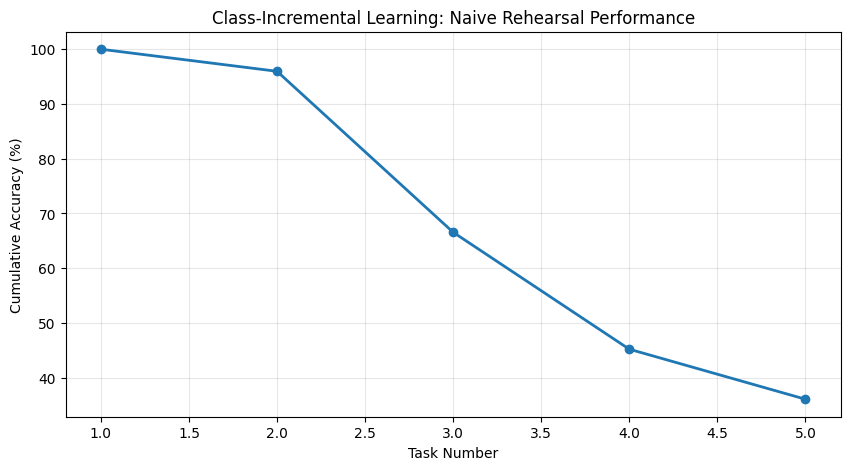

In [9]:
plot_learning_curves(training_losses, title="Naive Rehearsal Loss")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o', linewidth=2)
plt.xlabel('Task Number')
plt.ylabel('Cumulative Accuracy (%)')
plt.title('Class-Incremental Learning: Naive Rehearsal Performance')
plt.grid(True, alpha=0.3)
plt.show()